#### Распознавание арабских слов с помощью CRNN + CTC

In [5]:
# фиксируем все сиды для воспроизводимости результатов
import random
import numpy as np
import torch

SEED = 8072003

def set_seed(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [6]:
!pip install datasets -q

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset
from PIL import Image
import json

In [8]:
import os

# локальный каталог для артефактов текущей сессии
OUTPUT_DIR = '/content/arabic_ocr'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# забираем рукописные образцы для стресс-тестов из моего публичного репозитория
!rm -rf /content/stress_data
!git clone -q https://github.com/egortsebruk/arabic-ocr-crnn.git /content/stress_data

Для начала посмотрим на практике, как выглядят наши данные

In [9]:
# берем 5 рандомных сэмплов, смотрим что в них есть
ds = load_dataset(
  'mssqpi/Arabic-OCR-Dataset',
  split='train',
  streaming=True
)

samples = list(ds.take(5))

samples[0].keys()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.77k [00:00<?, ?B/s]

dict_keys(['image', 'text'])

In [10]:
# смотрим подробнее, что есть в сэмплах
for i, s in enumerate(samples):
  for k, v in s.items():
    if hasattr(v, 'size'): # если картинка
        print(f'{i + 1}) {k}: PIL Image, size={v.size}, mode={v.mode}')
    else:
        print(f'{i + 1}) {k}: {repr(v)}')

1) image: PIL Image, size=(74, 35), mode=L
1) text: 'المتميزة'
2) image: PIL Image, size=(74, 35), mode=L
2) text: 'لمساحات'
3) image: PIL Image, size=(72, 35), mode=L
3) text: 'الغذائية'
4) image: PIL Image, size=(63, 35), mode=L
4) text: 'الطولية'
5) image: PIL Image, size=(82, 35), mode=L
5) text: 'الصانعون'


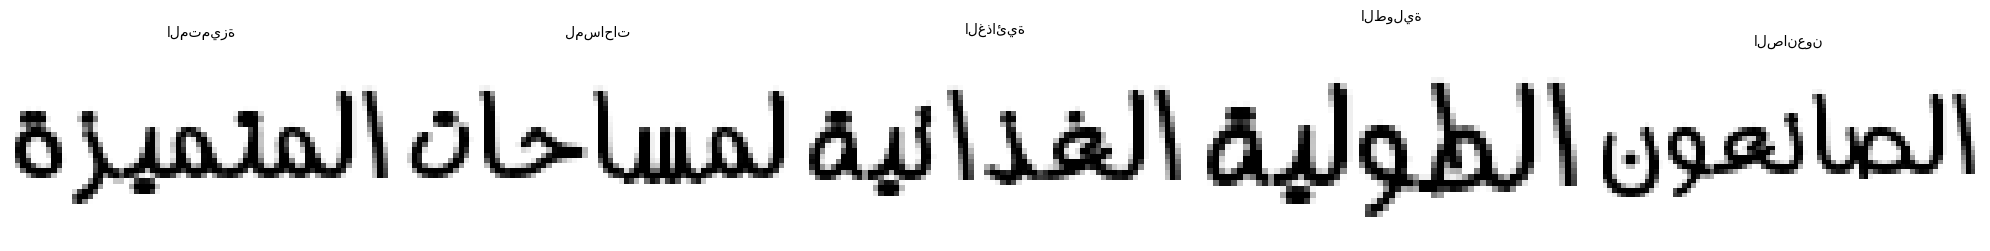

In [11]:
# создаем 5 графиков, для кажого сэмпла рисуем само изображение и подписываем арабским текстом
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, s in enumerate(samples):
  ax = axes[i]
  ax.imshow(s['image'], cmap='gray')
  ax.set_title(s['text'], fontsize=10)
  ax.axis('off')

plt.tight_layout()
plt.show()

Лично мне все понятно)

Но вижу деталь, которая не радует глаз: названия слов написаны неверно: слева-направо отдельными буквами, как, например, в русском. Но в арабском языке слова пишутся справа-налево и вид буквы меняется в зависимости от ее положения в слове, создавая знаменитую "арабскую вязь". Пока что это проблема на уровне визуализации, но сразу исправим

In [12]:
!pip install arabic-reshaper python-bidi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 15.5 MB/s eta 0:00:00


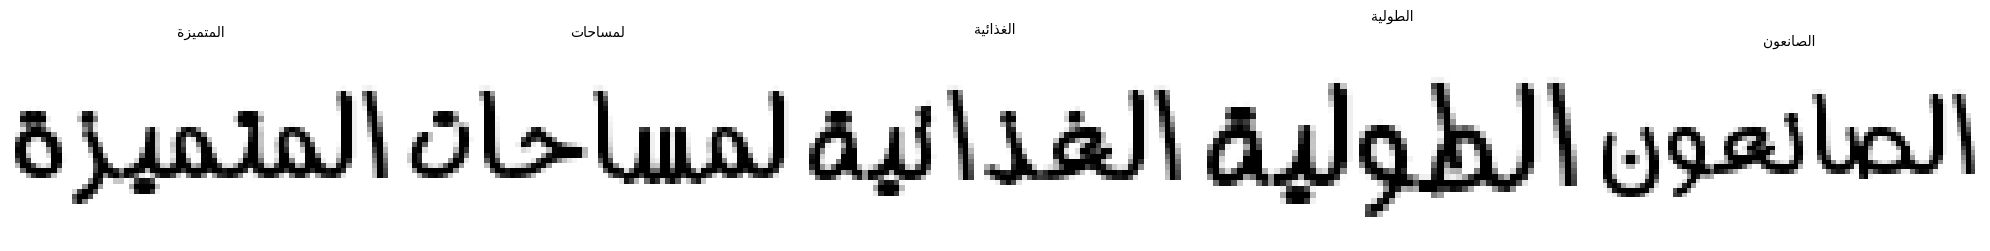

In [13]:
import arabic_reshaper
from bidi.algorithm import get_display

def fix_arabic(text): # функция принимает на вход обычный арабский текст и преобразует его в апрвильный вид
  reshaped = arabic_reshaper.reshape(text)
  return get_display(reshaped)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, s in enumerate(samples):
  ax = axes[i]
  ax.imshow(s['image'], cmap='gray')
  ax.set_title(fix_arabic(s['text']), fontsize=10)
  ax.axis('off')

plt.tight_layout()
plt.show()

Другое дело

Думаю, даже человек, который не знаком с арабским языком заметит разницу в названиях изображений, если приглядеться

Теперь посмотрим на все возможные символы в данном датасете, чтобы понять, какие из них должна предсказывать модель. Ситуация здесь не такая простая, как в привычных нам языках: в арабском существуют специальные буквы, которых не существует в алфавите, огласовки (обозначение гласных звуков) и лигатуры. Мы не знаем, что из этого есть в данном датасете, поэтому проверим на практике:

In [14]:
ds1 = load_dataset(
  'mssqpi/Arabic-OCR-Dataset',
  split='train',
  streaming=True
)

char_counter = Counter()

for i, sample in enumerate(ds1): # пробегаемся по первым 5000 сэмплов
  char_counter.update(sample['text']) # считаем все количество каждого уникального символа
  if i >= 4999:
    break

print(f'Уникальных символов: {len(char_counter)}')
for char, count in char_counter.most_common():
  print(f'Unicode: U+{ord(char):04X} [{char}] - {count} раз')

Уникальных символов: 37
Unicode: U+0627 [ا] - 7598 раз
Unicode: U+0644 [ل] - 4869 раз
Unicode: U+064A [ي] - 3042 раз
Unicode: U+0648 [و] - 2728 раз
Unicode: U+062A [ت] - 2330 раз
Unicode: U+0645 [م] - 2223 раз
Unicode: U+0646 [ن] - 1719 раз
Unicode: U+0631 [ر] - 1657 раз
Unicode: U+0629 [ة] - 1320 раз
Unicode: U+0628 [ب] - 1261 раз
Unicode: U+0633 [س] - 1116 раз
Unicode: U+0647 [ه] - 887 раз
Unicode: U+062F [د] - 886 раз
Unicode: U+0639 [ع] - 850 раз
Unicode: U+0641 [ف] - 674 раз
Unicode: U+0642 [ق] - 663 раз
Unicode: U+0643 [ك] - 542 раз
Unicode: U+062D [ح] - 512 раз
Unicode: U+062C [ج] - 484 раз
Unicode: U+0623 [أ] - 462 раз
Unicode: U+0637 [ط] - 375 раз
Unicode: U+0635 [ص] - 305 раз
Unicode: U+0634 [ش] - 295 раз
Unicode: U+0625 [إ] - 269 раз
Unicode: U+0632 [ز] - 267 раз
Unicode: U+062E [خ] - 261 раз
Unicode: U+0626 [ئ] - 211 раз
Unicode: U+0636 [ض] - 193 раз
Unicode: U+063A [غ] - 164 раз
Unicode: U+062B [ث] - 155 раз
Unicode: U+0621 [ء] - 101 раз
Unicode: U+0638 [ظ] - 68 раз
Unicod

Есть как обычные буквы, которые встречаются в алфавите*, так и некоторые другие

*(в арабском алфавите 28 букв)

Закодируем все наши символы

In [15]:
# сортируем все символы по юникоду, индекс 0 оставляем под blank
all_chars = sorted(char_counter.keys())

BLANK_IDX = 0
# создаем 2 словаря - для кодирования и декодирования
char2idx = {ch: idx + 1 for idx, ch in enumerate(all_chars)}
idx2char = {idx + 1: ch for idx, ch in enumerate(all_chars)}
idx2char[BLANK_IDX] = '<BLANK>'

In [16]:
import os
import shutil

NUM_CLASSES = len(all_chars) + 1
# создаем словарь символов
vocab = {
  'chars': all_chars, # сами символы
  'char2idx': char2idx, # символ-индекс
  'idx2char': {str(k): v for k, v in idx2char.items()}, #индекс-символ
  'num_classes': NUM_CLASSES, # кол-во классов
  'blank_idx': BLANK_IDX # индекс для blank
}

with open('vocab.json', 'w', encoding='utf-8') as f:
  json.dump(vocab, f, ensure_ascii=False, indent=2)

# сохраняем словарь
os.makedirs('/content/arabic_ocr', exist_ok=True)
shutil.copy('vocab.json', '/content/arabic_ocr/vocab.json')

'/content/arabic_ocr/vocab.json'

In [17]:
# загрузим 100000 сэмплов
TARGET_HEIGHT = 32 # высоту делаем степенью двойки, причем наиболее близкой к реальной высоте, чтобы CNN было удобнее работать
N_SAMPLES = 100_000
ds_full = load_dataset(
  'mssqpi/Arabic-OCR-Dataset',
  split='train',
  streaming=True # читаем по одному сэмплу
)
images = []
labels = []
widths = []
skipped = 0

for i, s in enumerate(ds_full):
  if i >= N_SAMPLES:
    break

  img = s['image']
  text = s['text']

  try: # на случай, если попадется буква, которую мы не видели раньше
    label = [char2idx[ch] for ch in text]
  except KeyError:
    skipped += 1
    continue

  orig_w, orig_h = img.size
  new_w = int(orig_w * TARGET_HEIGHT / orig_h) # ресайзим высоту до TARGET_HEIGHT
  img = img.resize((new_w, TARGET_HEIGHT), Image.LANCZOS)
  img_array = np.array(img, dtype=np.uint8)
  images.append(img_array)
  labels.append(label)
  widths.append(new_w)

  if (i + 1) % 10_000 == 0:
    print(f'Загружено: {i + 1}/{N_SAMPLES}')

print(f'Мин/макс ширина: {min(widths)} / {max(widths)}')

Загружено: 10000/100000
Загружено: 20000/100000
Загружено: 30000/100000
Загружено: 40000/100000
Загружено: 50000/100000
Загружено: 60000/100000
Загружено: 70000/100000
Загружено: 80000/100000
Загружено: 90000/100000
Загружено: 100000/100000
Мин/макс ширина: 38 / 116


In [18]:
import pickle

# сохраняем эти сэмплы
with open('/content/arabic_ocr/data.pkl', 'wb') as f:
  pickle.dump({
    'images': images,
    'labels': labels,
  }, f)

Датасет загрузили и сохранили. Чтобы нашей архитектуре было удобнее работать, немного поменяли размер изображений, каких-то выбросов по слишком большой / маленькой ширине нету

Разобьем датасет на тренировочную, валидационную и тестовые выборки, но по индексам, чтобы было эффективнее по памяти

In [19]:
from sklearn.model_selection import train_test_split

indices = list(range(len(images)))

train_idx, valtest_idx = train_test_split(indices, test_size=0.2, random_state=42) # сначала делаем тренировочную и временную выборки
val_idx, test_idx = train_test_split(valtest_idx, test_size=0.5, random_state=42) # временную теперь разбиваем на валидационную и тестовую

Создадим класс датасета

In [20]:
import torch
from torch.utils.data import Dataset

class ArabicOCRDataset(Dataset):
  def __init__(self, images, labels, indices):
    self.images = images # все картинки
    self.labels = labels # все названия
    self.indices = indices # индексы конкретного сплита

  def __len__(self):
    # возвращает количество сэмплов в этом сплите
    return len(self.indices)

  def __getitem__(self, idx):
    real_idx = self.indices[idx] # переводим локальный индекс в глобальный
    img = self.images[real_idx]
    label = self.labels[real_idx]

    img = img.astype('float32') / 255.0 # нормализуем

    img = 1.0 - img # так как текст темный, а фон светлый - инвертируем

    # добавляем размерность канала
    img = torch.tensor(img).unsqueeze(0)
    label = torch.tensor(label, dtype=torch.long)

    return img, label

In [21]:
train_dataset = ArabicOCRDataset(images, labels, train_idx)
val_dataset = ArabicOCRDataset(images, labels, val_idx)
test_dataset = ArabicOCRDataset(images, labels, test_idx)

len(train_dataset), len(val_dataset), len(test_dataset)

(80000, 10000, 10000)

Проверим, что все выглядит правильно

In [22]:
img, label = train_dataset[0]
print(f'Форма картинки: {img.shape}')
print(f'Метка: {label}')
print(f'Decoded: {''.join([idx2char[i.item()] for i in label])}')

Форма картинки: torch.Size([1, 32, 71])
Метка: tensor([ 7, 31, 10, 18,  3, 32, 33, 37,  9])
Decoded: التزأمنية


Напишем свою функцию сборки батча, так как у нас разная ширина у картинок и просто складывать тензоры через torch.stack - не очень хорошая идея

In [23]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
  images, labels = zip(*batch) # распаковываем список пар в две группы
  max_w = max(img.shape[2] for img in images) # берем самую большую ширину в батче
  padded_images = torch.zeros(len(images), 1, 32, max_w) # заполняем нулями максимальный размер картинки (черный фон)
  for i, img in enumerate(images): # вставляем картинку в левую часть
    w = img.shape[2]
    padded_images[i, :, :, :w] = img

  label_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long) # список длин всех меток нужен будет для CTC лосса, чтобы знать где заканчивается одно слово и начинается другое
  labels_concat = torch.cat(labels) # склеиваем все метки в один длинный тензор

  return padded_images, labels_concat, label_lengths

# отдельный генератор, который фиксирует порядок перемешивания батчей
g = torch.Generator()
g.manual_seed(SEED)

# shuffle=True только для train - перемешиваем каждую эпоху
train_loader = DataLoader(
  train_dataset,
  batch_size=64,
  shuffle=True,
  generator=g,
  collate_fn=collate_fn
)
val_loader = DataLoader(
  val_dataset,
  batch_size=64,
  shuffle=False,
  collate_fn=collate_fn
)

Проверка на всякий случай

In [24]:
batch_imgs, batch_labels, batch_label_lengths = next(iter(train_loader))
batch_imgs.shape, batch_labels.shape

(torch.Size([64, 1, 32, 97]), torch.Size([507]))

In [25]:
batch_label_lengths

tensor([ 8, 10,  7,  9,  8,  9, 10,  7,  8,  7,  9,  7,  7,  8, 10,  7,  8,  9,
         7,  7,  7,  7,  8,  8,  7, 10,  7,  8,  9,  7, 10,  8,  7,  8,  9,  7,
         7,  8,  7, 10,  9,  7,  8,  8,  7,  7,  8,  7,  8,  7,  8,  7,  8,  7,
        10,  7,  8,  9,  7,  8,  9,  7,  7,  8])

Все работает, теперь напишем саму нейросеть, для начала начнем с блока CNN

In [26]:
import torch.nn as nn

class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.features = nn.Sequential(
      # блок 1 - 32 фильтра, высоту и ширину уменьшаем в 2 раза
      nn.Conv2d(1, 32, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(2, 2),

      # блок 2 - 64 фильтра, снова уменьшаем в 2 раза
      nn.Conv2d(32, 64, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.MaxPool2d(2, 2),

      # блок 3 - 128 фильтров, уменьшаем только высоту, так как ширина будет нужна для последовательности
      nn.Conv2d(64, 128, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.MaxPool2d((2, 1)),

      # блок 4 - еще раз уменьшаем только высоту
      nn.Conv2d(128, 128, kernel_size=3, padding=1),
      nn.ReLU(),
      nn.MaxPool2d((2, 1)),
    )

  def forward(self, x):
    return self.features(x)

# проверяем
cnn_test = CNN()
test_input = torch.zeros(1, 1, 32, 116)
test_output = cnn_test(test_input)
test_input.shape, test_output.shape

(torch.Size([1, 1, 32, 116]), torch.Size([1, 128, 2, 29]))

Пишем все вместе

In [27]:
class CRNN(nn.Module):
  def __init__(self, num_classes):
    super().__init__()

    self.cnn = CNN()

    self.bilstm = nn.LSTM(
      input_size=256, # C*H = 128*2 после CNN
      hidden_size=256,
      num_layers=2, # два слоя LSTM
      batch_first=True,
      bidirectional=True # читаем слева направо и справа налево
    )

    self.fc = nn.Linear(512, num_classes) # 512 = 256*2 из-за bidirectional

  def forward(self, x):
    x = self.cnn(x)
    B, C, H, W = x.shape
    x = x.view(B, C * H, W)
    x = x.permute(0, 2, 1) # меняем порядок для LSTM
    x, _ = self.bilstm(x)
    x = self.fc(x)
    x = x.permute(1, 0, 2)
    return x

# проверка
model = CRNN(num_classes=NUM_CLASSES)
test_output = model(test_input)
test_output.shape

torch.Size([29, 1, 38])

Инициализируем модель с СТС лоссом

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model = CRNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CTCLoss(blank=BLANK_IDX, reduction='mean', zero_infinity=True) # zero_infinity=True защищает от NaN при невозможном выравнивании
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

cuda


In [29]:
def decode(outputs): # функция декодирования
  # берём индекс с максимальной вероятностью на каждом шаге
  indices = outputs.argmax(dim=2)
  indices = indices.permute(1, 0)

  results = []
  for seq in indices:
    chars = []
    prev = None
    for idx in seq:
      idx = idx.item()
      # убираем blank и повторяющиеся символы
      if idx != BLANK_IDX and idx != prev:
        chars.append(idx2char[idx])
      prev = idx
    results.append(''.join(chars))
  return results

In [30]:
def cer(predicted, target): # Character Error Rate - процент неправильных символов
  total_chars = len(target)
  if total_chars == 0:
    return 0.0

  # расстояние Левенштейна
  n, m = len(predicted), len(target)
  dp = list(range(m + 1))
  for i in range(1, n + 1):
    new_dp = [i] + [0] * m
    for j in range(1, m + 1):
      if predicted[i-1] == target[j-1]: # символы совпали - без штрафа
        new_dp[j] = dp[j-1]
      else:
        new_dp[j] = 1 + min(dp[j], new_dp[j-1], dp[j-1]) # минимум из трех операций: удаление, вставка, замена
    dp = new_dp
  return dp[m] / total_chars # нормируем на длину истинного слова

def wer(predicted, target): # Word Error Rate - 0 если слово угадано, 1 если нет
  return 0.0 if predicted == target else 1.0

Обучаем - изначально обучение велось с lr=1e-3, но cer, wer практически не двигались, как я поменял на lr=3e-4 сразу стало сильно лучше

In [31]:
NUM_EPOCHS = 50
best_val_loss = float('inf')

train_losses = []
val_losses = []
val_cers = []
val_wers = []

for epoch in range(NUM_EPOCHS):
  # train
  model.train() # включаем режим обучения
  train_loss = 0

  for batch_imgs, batch_labels, batch_label_lengths in train_loader:
    batch_imgs = batch_imgs.to(device)
    batch_labels = batch_labels.to(device)
    batch_label_lengths = batch_label_lengths.to(device)

    optimizer.zero_grad() # обнуляем градиенты перед каждым батчем
    outputs = model(batch_imgs)
    T = outputs.shape[0]
    input_lengths = torch.full((outputs.shape[1],), T, dtype=torch.long).to(device)

    loss = criterion(outputs, batch_labels, input_lengths, batch_label_lengths)
    loss.backward() # считаем градиенты
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0) # clipping для предотвращения взрыва градиентов
    optimizer.step() # обновляем веса

    train_loss += loss.item()

  train_loss /= len(train_loader)
  train_losses.append(train_loss)

  # validation
  model.eval() # отключаем dropout
  val_loss = 0
  epoch_cer = 0
  epoch_wer = 0
  n_samples = 0

  with torch.no_grad(): # не считаем градиенты
    for batch_imgs, batch_labels, batch_label_lengths in val_loader:
      batch_imgs = batch_imgs.to(device)
      batch_labels = batch_labels.to(device)
      batch_label_lengths = batch_label_lengths.to(device)

      outputs = model(batch_imgs)
      T = outputs.shape[0]
      input_lengths = torch.full((outputs.shape[1],), T, dtype=torch.long).to(device)

      loss = criterion(outputs, batch_labels, input_lengths, batch_label_lengths)
      val_loss += loss.item()

      predicted = decode(outputs.cpu())

      # восстанавливаем метки из конкатенированного тензора через offset
      offset = 0
      for i, length in enumerate(batch_label_lengths):
        length = length.item()
        true_label = ''.join([idx2char[idx.item()] for idx in batch_labels[offset:offset+length]])
        offset += length

        epoch_cer += cer(predicted[i], true_label)
        epoch_wer += wer(predicted[i], true_label)
        n_samples += 1

  val_loss /= len(val_loader)
  epoch_cer /= n_samples
  epoch_wer /= n_samples

  val_losses.append(val_loss)
  val_cers.append(epoch_cer)
  val_wers.append(epoch_wer)

  # сохраняем модель только если val_loss улучшился
  if val_loss < best_val_loss:
    best_val_loss = val_loss
    torch.save(model.state_dict(), '/content/arabic_ocr/best_model.pth')
    print(f'Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, CER={epoch_cer:.4f}, WER={epoch_wer:.4f} - сохраняем')
  else:
    print(f'Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, CER={epoch_cer:.4f}, WER={epoch_wer:.4f}')

Epoch 1: train_loss=2.9111, val_loss=2.8140, CER=0.8057, WER=1.0000 - сохраняем
Epoch 2: train_loss=2.6288, val_loss=2.3850, CER=0.6372, WER=1.0000 - сохраняем
Epoch 3: train_loss=2.0976, val_loss=1.8373, CER=0.4966, WER=0.9998 - сохраняем
Epoch 4: train_loss=1.5168, val_loss=1.1888, CER=0.3351, WER=0.9830 - сохраняем
Epoch 5: train_loss=0.9530, val_loss=0.7210, CER=0.1945, WER=0.8114 - сохраняем
Epoch 6: train_loss=0.5898, val_loss=0.4151, CER=0.1095, WER=0.5363 - сохраняем
Epoch 7: train_loss=0.3996, val_loss=0.3829, CER=0.0703, WER=0.3719 - сохраняем
Epoch 8: train_loss=0.2947, val_loss=0.2385, CER=0.0473, WER=0.2622 - сохраняем
Epoch 9: train_loss=0.2285, val_loss=0.2221, CER=0.0363, WER=0.2052 - сохраняем
Epoch 10: train_loss=0.1821, val_loss=0.1912, CER=0.0261, WER=0.1513 - сохраняем
Epoch 11: train_loss=0.1477, val_loss=0.0736, CER=0.0203, WER=0.1213 - сохраняем
Epoch 12: train_loss=0.1224, val_loss=0.1108, CER=0.0156, WER=0.0958
Epoch 13: train_loss=0.1018, val_loss=0.1431, CER

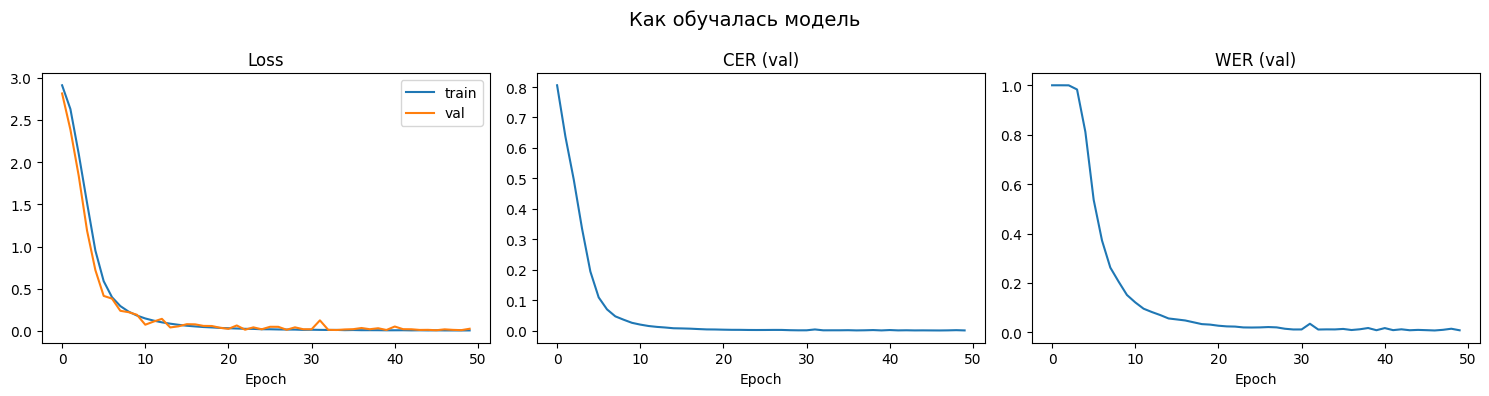

In [32]:
# отрисуем динамику обучения
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_losses, label='train')
axes[0].plot(val_losses, label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(val_cers)
axes[1].set_title('CER (val)')
axes[1].set_xlabel('Epoch')

axes[2].plot(val_wers)
axes[2].set_title('WER (val)')
axes[2].set_xlabel('Epoch')

plt.suptitle('Как обучалась модель', fontsize=14)
plt.tight_layout()
plt.savefig('/content/arabic_ocr/training_curves.png', dpi=150)
plt.show()

Проверим, как себя ведет модель на тестовой выборке

In [33]:
# загрузим лучшую модель
model.load_state_dict(torch.load('/content/arabic_ocr/best_model.pth'))
model.eval()

test_loader = DataLoader(
  test_dataset,
  batch_size=64,
  shuffle=False,
  collate_fn=collate_fn
)

test_cer = 0
test_wer = 0
n_samples = 0

with torch.no_grad():
  for batch_imgs, batch_labels, batch_label_lengths in test_loader:
    batch_imgs = batch_imgs.to(device)
    outputs = model(batch_imgs)
    predicted = decode(outputs.cpu())

    offset = 0
    for i, length in enumerate(batch_label_lengths):
      length = length.item()
      true_label = ''.join([idx2char[idx.item()] for idx in batch_labels[offset:offset+length]])
      offset += length

      test_cer += cer(predicted[i], true_label)
      test_wer += wer(predicted[i], true_label)
      n_samples += 1

test_cer /= n_samples
test_wer /= n_samples

print(f'Test CER: {test_cer:.4f}')
print(f'Test WER: {test_wer:.4f}')

Test CER: 0.0012
Test WER: 0.0094


Посмотрим на примере отдого батча на то, как реально модель распознает наш текст

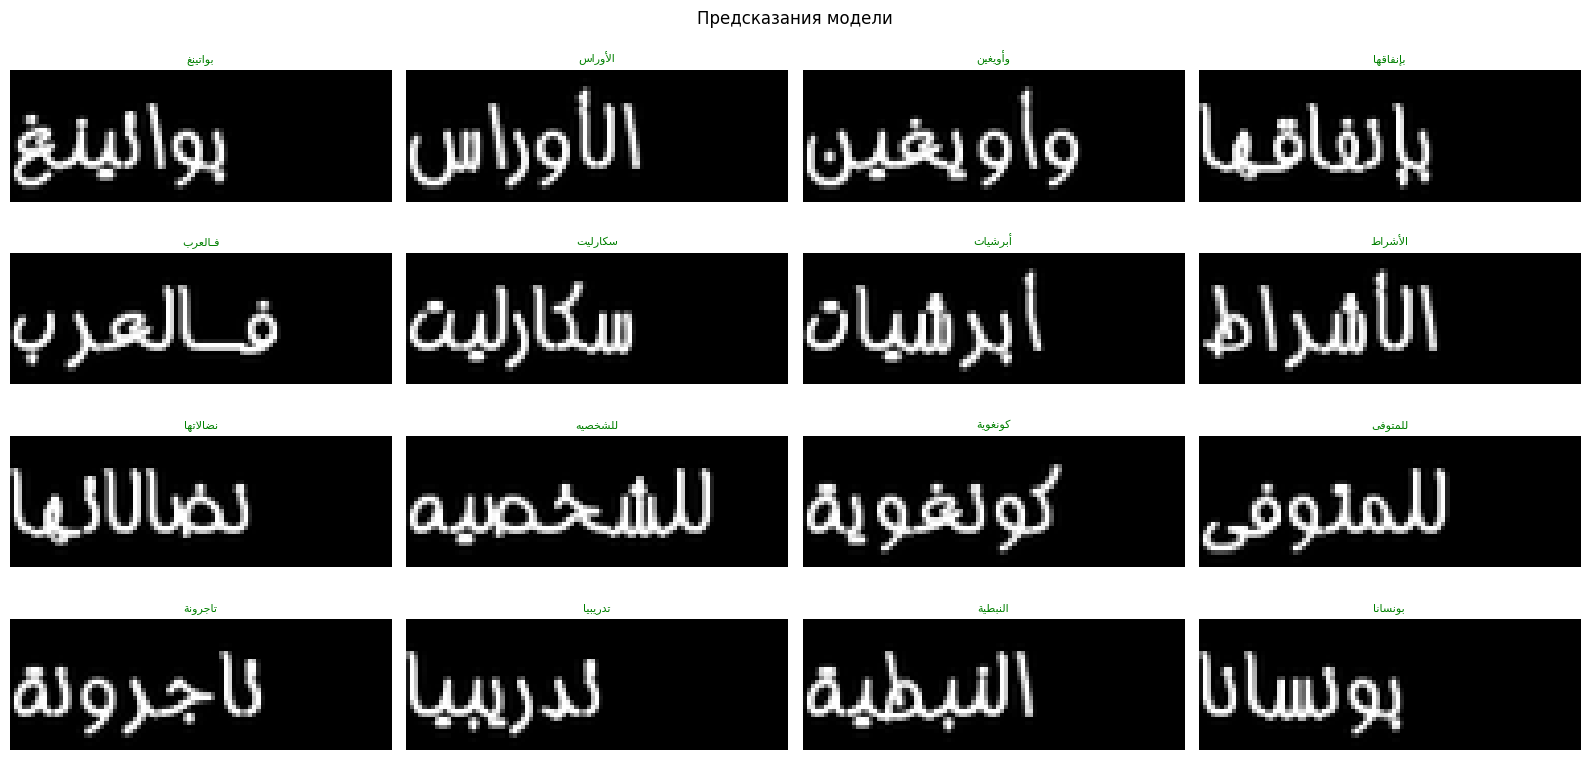

In [34]:
fig, axes = plt.subplots(4, 4, figsize=(16, 8))
axes = axes.flatten()

batch_imgs, batch_labels, batch_label_lengths = next(iter(test_loader))
outputs = model(batch_imgs.to(device))
predicted = decode(outputs.cpu())

offset = 0
for i in range(16):
  length = batch_label_lengths[i].item()
  true_label = ''.join([idx2char[idx.item()] for idx in batch_labels[offset:offset+length]])
  offset += length

  img = batch_imgs[i, 0].numpy()
  axes[i].imshow(img, cmap='gray')

  pred = predicted[i]
  correct = pred == true_label

  title = f'{fix_arabic(true_label)}' if correct else f'{fix_arabic(pred)}\n- {fix_arabic(true_label)}'
  color = 'green' if correct else 'red'
  axes[i].set_title(title, color=color, fontsize=8)
  axes[i].axis('off')

plt.suptitle('Предсказания модели', fontsize=12)
plt.tight_layout()
plt.savefig('/content/arabic_ocr/predictions_examples.png', dpi=150)
plt.show()

В исследовательских целях попробуем поменять декодировку, будем использовать Beam Search

In [35]:
def decode_beam(outputs, beam_width=5):
  outputs = torch.softmax(outputs, dim=2)
  T, B, C = outputs.shape
  results = []

  for b in range(B):
    beams = [([], 0.0)]
    for t in range(T):
      probs = outputs[t, b] # переводим логиты в вероятности
      new_beams = []
      for seq, score in beams:
        for c in range(C):
          # суммируем логарифмы вместо умножения вероятностей
          new_score = score + torch.log(probs[c] + 1e-9).item()
          new_beams.append((seq + [c], new_score))

      # оставляем только beam_width лучших гипотез
      new_beams.sort(key=lambda x: x[1], reverse=True)
      beams = new_beams[:beam_width]

    # декодируем лучшую гипотезу - убираем blank и повторы
    best_seq = beams[0][0]
    chars = []
    prev = None
    for idx in best_seq:
      if idx != BLANK_IDX and idx != prev:
        chars.append(idx2char[idx])
      prev = idx
    results.append(''.join(chars))

  return results

Далее комментарии по коду отсутствуют - все тесты выполняются по тем же принципам, что и ранее, визуализации и подсчеты тривиальны

Сравним результаты:

In [36]:
test_cer_beam = 0
test_wer_beam = 0
n_samples = 0

with torch.no_grad():
  for batch_imgs, batch_labels, batch_label_lengths in test_loader:
    batch_imgs = batch_imgs.to(device)

    outputs = model(batch_imgs.to(device))
    predicted = decode_beam(outputs.cpu(), beam_width=5)

    offset = 0
    for i, length in enumerate(batch_label_lengths):
      length = length.item()
      true_label = ''.join([idx2char[idx.item()] for idx in batch_labels[offset:offset+length]])
      offset += length

      test_cer_beam += cer(predicted[i], true_label)
      test_wer_beam += wer(predicted[i], true_label)
      n_samples += 1

test_cer_beam /= n_samples
test_wer_beam /= n_samples

print(f'Greedy (изначальное): CER={test_cer:.4f}  WER={test_wer:.4f}')
print(f'Beam Search (новое): CER={test_cer_beam:.4f}  WER={test_wer_beam:.4f}')

Greedy (изначальное): CER=0.0012  WER=0.0094
Beam Search (новое): CER=0.0012  WER=0.0094


Посмотрим также, на каких символах модель ошибалась чаще всего

In [37]:
from collections import defaultdict

char_errors = defaultdict(int)
char_total = defaultdict(int)

with torch.no_grad():
  for batch_imgs, batch_labels, batch_label_lengths in test_loader:
    batch_imgs = batch_imgs.to(device)
    outputs = model(batch_imgs.to(device))
    predicted = decode(outputs.cpu())

    offset = 0
    for i, length in enumerate(batch_label_lengths):
      length = length.item()
      true_label = ''.join([idx2char[idx.item()] for idx in batch_labels[offset:offset+length]])
      offset += length
      for ch in true_label:
        char_total[ch] += 1
      if predicted[i] != true_label:
        for ch in true_label:
          if ch not in predicted[i]:
            char_errors[ch] += 1

print('Сначала идет процент ошибок, затем то, сколько раз встретился символ, потом количество ошибок и сам символ')
error_rates = {}
for ch in char_total:
  rate = char_errors[ch] / char_total[ch]
  error_rates[ch] = rate

for ch, rate in sorted(error_rates.items(), key=lambda x: x[1], reverse=True)[:15]:
  print(f'{ch} |  {char_errors[ch]:5d}  |  {char_total[ch]:5d}  |  {rate:.4f}')

Сначала идет процент ошибок, затем то, сколько раз встретился символ, потом количество ошибок и сам символ
آ |      2  |     58  |  0.0345
ى |      3  |    172  |  0.0174
ء |      2  |    170  |  0.0118
ئ |      2  |    301  |  0.0066
ث |      2  |    307  |  0.0065
إ |      3  |    474  |  0.0063
ص |      3  |    522  |  0.0057
غ |      2  |    472  |  0.0042
ش |      3  |    814  |  0.0037
ط |      2  |    636  |  0.0031
ض |      1  |    319  |  0.0031
ز |      2  |    723  |  0.0028
ق |      3  |   1142  |  0.0026
أ |      2  |    951  |  0.0021
ع |      2  |   1291  |  0.0015


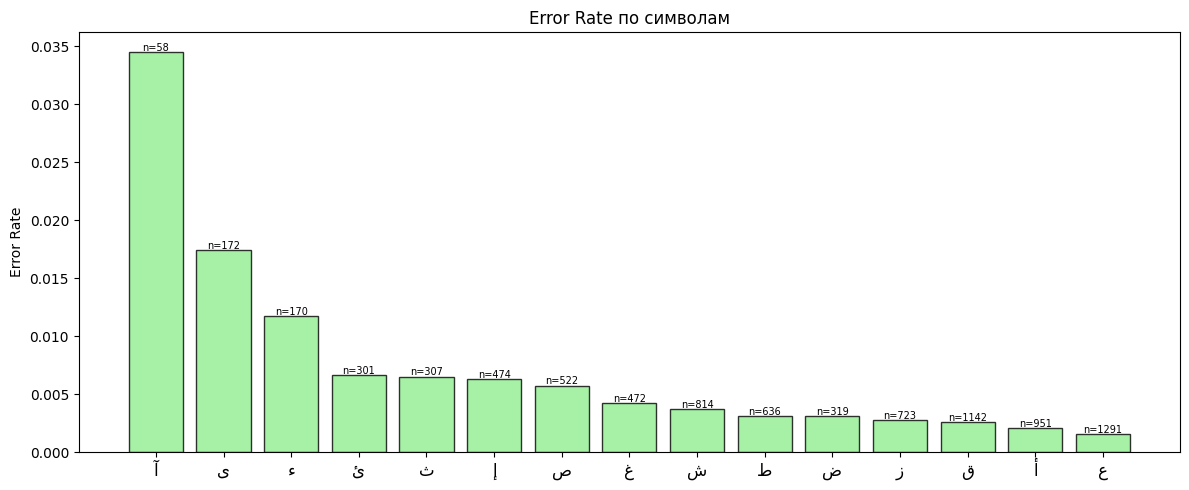

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))

chars = [ch for ch, _ in sorted(error_rates.items(), key=lambda x: x[1], reverse=True)[:15]]
rates = [error_rates[ch] for ch in chars]
totals = [char_total[ch] for ch in chars]

bars = ax.bar(range(len(chars)), rates, color='lightgreen', edgecolor='black', alpha=0.8)
ax.set_xticks(range(len(chars)))
ax.set_xticklabels([fix_arabic(ch) for ch in chars], fontsize=12)
ax.set_ylabel('Error Rate')
ax.set_title('Error Rate по символам')

for i, (bar, total) in enumerate(zip(bars, totals)):
  ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
    f'n={total}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('/content/arabic_ocr/error_analysis.png', dpi=150)
plt.show()

Теперь попробуем прогнать модель на моих рукописных записях + записях моего репетитора (у которого родной язык - арабский)

In [40]:
handwritten_data = [
  ('author_01.jpg', 'مستشفى'),
  ('author_02.jpg', 'الجامعة'),
  ('author_03.jpg', 'السماء'),
  ('author_04.jpg', 'الصحراء'),
  ('author_05.jpg', 'الطريق'),
  ('author_06.jpg', 'البيت'),
  ('author_07.jpg', 'المكتبة'),
  ('author_08.jpg', 'المدينة'),
  ('author_09.jpg', 'المطبخ'),
  ('author_10.jpeg', 'مدرستنا'),
]

results = []

for filename, true_label in handwritten_data:
  path = f'/content/stress_data/{filename}'
  img = Image.open(path).convert('L')

  orig_w, orig_h = img.size
  new_w = int(orig_w * TARGET_HEIGHT / orig_h)
  new_w = max(new_w, 8)

  img = img.resize((new_w, TARGET_HEIGHT), Image.LANCZOS)
  img_array = np.array(img, dtype='float32') / 255.0
  img_array = 1.0 - img_array
  img_tensor = torch.tensor(img_array).unsqueeze(0).unsqueeze(0)

  with torch.no_grad():
    output = model(img_tensor.to(device))
    predicted = decode(output.cpu())[0]

  word_cer = cer(predicted, true_label)
  word_wer = wer(predicted, true_label)
  results.append((true_label, predicted, word_cer, word_wer))

  print(f'Истинное: {true_label:12s}, предсказанное: {predicted:12s}, CER: {word_cer:.2f}')

avg_cer = sum(r[2] for r in results) / len(results)
avg_wer = sum(r[3] for r in results) / len(results)
print(f'Средний CER: {avg_cer:.4f}')
print(f'Средний WER: {avg_wer:.4f}')

Истинное: مستشفى      , предсказанное: حيب         , CER: 1.00
Истинное: الجامعة     , предсказанное: أجححوب      , CER: 0.86
Истинное: السماء      , предсказанное: أيــأف      , CER: 1.00
Истинное: الصحراء     , предсказанное: صححء        , CER: 0.57
Истинное: الطريق      , предсказанное: ححب         , CER: 1.00
Истинное: البيت       , предсказанное: ألببـف      , CER: 0.80
Истинное: المكتبة     , предсказанное: يييىئ       , CER: 1.00
Истинное: المدينة     , предсказанное: بدحببف      , CER: 1.00
Истинное: المطبخ      , предсказанное: أاف         , CER: 1.00
Истинное: مدرستنا     , предсказанное: صنحأئ       , CER: 1.00
Средний CER: 0.9229
Средний WER: 1.0000


In [41]:
tutor_data = [
  ('tutor_01.png', 'مدرستنا'),
  ('tutor_02.png', 'المكتبة'),
  ('tutor_03.png', 'الطريق'),
  ('tutor_04.png', 'مستشفى'),
  ('tutor_05.png', 'الجامعة'),
  ('tutor_06.png', 'السماء'),
  ('tutor_07.png', 'المدينة'),
  ('tutor_08.png', 'البيت'),
  ('tutor_09.png', 'الصحراء'),
  ('tutor_10.png', 'المطبخ'),
]

tutor_results = []

for filename, true_label in tutor_data:
  path = f'/content/stress_data/{filename}'
  img = Image.open(path).convert('L')

  orig_w, orig_h = img.size
  new_w = int(orig_w * TARGET_HEIGHT / orig_h)
  new_w = max(new_w, 8)

  img = img.resize((new_w, TARGET_HEIGHT), Image.LANCZOS)
  img_array = np.array(img, dtype='float32') / 255.0
  img_array = 1.0 - img_array
  img_tensor = torch.tensor(img_array).unsqueeze(0).unsqueeze(0)

  with torch.no_grad():
    output = model(img_tensor.to(device))
    predicted = decode(output.cpu())[0]

  word_cer = cer(predicted, true_label)
  word_wer = wer(predicted, true_label)
  tutor_results.append((true_label, predicted, word_cer, word_wer))

  print(f'Истинное: {true_label:12s}, предсказанное: {predicted:12s}, CER: {word_cer:.2f}')

avg_t_cer = sum(r[2] for r in tutor_results) / len(tutor_results)
avg_t_wer = sum(r[3] for r in tutor_results) / len(tutor_results)
print(f'\nСредний CER: {avg_t_cer:.4f}')
print(f'Средний WER: {avg_t_wer:.4f}')

Истинное: مدرستنا     , предсказанное: اسلرداغفاأبد, CER: 1.43
Истинное: المكتبة     , предсказанное: ارلاغنواهبع , CER: 1.14
Истинное: الطريق      , предсказанное: فداهء       , CER: 1.00
Истинное: مستشفى      , предсказанное: لسطرعطةىودءع, CER: 1.67
Истинное: الجامعة     , предсказанное: سطلعطهاهءع  , CER: 1.14
Истинное: السماء      , предсказанное: سلرعافهااهءع, CER: 1.50
Истинное: المدينة     , предсказанное: سرلرعرافهاوهءع, CER: 1.86
Истинное: البيت       , предсказанное: رهفاهء      , CER: 1.20
Истинное: الصحراء     , предсказанное: رلهفراهدء   , CER: 0.71
Истинное: المطبخ      , предсказанное: رطفاآهء     , CER: 1.17

Средний CER: 1.2819
Средний WER: 1.0000


Финальные результаты:

In [42]:
print(f'Test: {test_cer:.4f}')
print(f'Beam search: {test_cer_beam:.4f}')
print(f'Мои рукописи: {avg_cer:.4f}')
print(f'Рукописи репетитора: {avg_t_cer:.4f}')

Test: 0.0012
Beam search: 0.0012
Мои рукописи: 0.9229
Рукописи репетитора: 1.2819
